# Proyecto RappiPlus: de datos a decisiones de negocio

**Introducción**


El objetivo de este proyecto es evaluar el desempeño del servicio **RappiPlus** para apoyar **decisiones de negocio basadas en datos**.

Se trabajan con múltiples datasets del negocio:

- **rappiplus_orders_raw.csv** → información de pedidos, precios, descuentos y revenue  
- **rappiplus_catalog.csv** → costos de productos, categorías y proveedores  
- **rappiplus_marketing_spend.csv** → inversión en marketing por canal y país  
- **events / users / user_activity (SQL)** → comportamiento del usuario dentro de la plataforma  
- **experiment_checkout_ui.csv** → resultados de un experimento A/B en el checkout  

El análisis sigue una lógica clara y progresiva:

1. Evaluar si podemos confiar en los datos (calidad de datos en Python) 

2. Analizar si el negocio es rentable (revenue, costos y profit)  

3. Entender dónde se pierden los usuarios (funnel de conversión)  

4. Evaluar si los usuarios regresan (retención por cohortes)  

5. Validar si los cambios generan impacto (test estadístico)  

6. omunicar los resultados (dashboard en BI)  

A lo largo del proyecto, se transforman datos en insights para responder preguntas clave del negocio y proponer **recomendaciones accionables**.

---

## 🔹 Paso 1: Cargar y validar la calidad de los datos

---

### 1.1 Carga de datos y vista rápida

**Objetivo:** Familiarizarte con la estructura de los datasets del negocio antes de analizarlos.

**Instrucciones:**

- Importa las librerías necesarias
- Carga los archivos:
  - `rappiplus_orders_raw.csv`
  - `rappiplus_catalog.csv`
  - `rappiplus_marketing_spend.csv`
- Guarda los DataFrames en:
  - `orders`, `catalog`, `marketing`
- Explora cada dataset.

---

In [65]:
# importar librerías

import pandas as pd
from statsmodels.stats.proportion import proportions_ztest

In [2]:
# cargar archivos
orders = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/rappiplus_orders_raw.csv')
catalog = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/rappiplus_catalog.csv')
marketing = pd.read_csv ('https://practicum-content.s3.amazonaws.com/datasets/rappiplus_marketing_spend.csv')

In [4]:
# explorar datasets
orders.info()
catalog.info()
marketing.info()


<class 'pandas.core.frame.DataFrame'>
,RangeIndex: 25100 entries, 0 to 25099
,Data columns (total 12 columns):
, #   Column              Non-Null Count  Dtype  
,---  ------              --------------  -----  
, 0   id_pedido           25100 non-null  object 
, 1   id_usuario          25100 non-null  object 
, 2   fecha_hora_pedido   25100 non-null  object 
, 3   pais                24800 non-null  object 
, 4   dispositivo         25080 non-null  object 
, 5   fuente_referencia   25070 non-null  object 
, 6   nombre_producto     25070 non-null  object 
, 7   categoria_producto  25020 non-null  object 
, 8   cantidad            25050 non-null  float64
, 9   precio_unitario     25050 non-null  float64
, 10  monto_descuento     25050 non-null  float64
, 11  monto_total         25100 non-null  float64
,dtypes: float64(4), object(8)
,memory usage: 2.3+ MB
,<class 'pandas.core.frame.DataFrame'>
,RangeIndex: 7 entries, 0 to 6
,Data columns (total 4 columns):
, #   Column              Non-Nu

In [5]:
print("ORDERS")
display(orders.head())

print("CATALOG")
display(catalog.head())

print("MARKETING")
display(marketing.head())


ORDERS


,id_pedido,id_usuario,fecha_hora_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total
0,order_0,user_6993,2025-05-22,Argentina,desktop,organic,Jacket-Winter-M,Moda,2.0,332.69,0.0,665.37
1,order_1,user_1329,2025-06-15,Mexico,desktop,paid_search,Tablet-Standard-64GB,Electronica,1.0,176.86,5.0,171.86
2,order_2,user_3194,2025-05-02,Argentina,desktop,social,Blender-XL-Red,Hogar,2.0,102.99,10.0,195.99
3,order_3,user_4510,2025-06-09,Colombia,mobile,social,Tablet-Standard-64GB,Electronica,1.0,257.87,15.0,242.87
4,order_4,user_5044,2025-03-30,Argentina,desktop,paid_search,Blender-XL-Red,Hogar,1.0,336.28,0.0,336.28


CATALOG


,nombre_producto,categoria_producto,costo_unitario,proveedor
0,Laptop-Gaming-16GB,Electrónica,280.68,"Fuller, Pena and Myers"
1,Phone-Pro-128GB,Electrónica,10.12,King Ltd
2,Tablet-Standard-64GB,Electrónica,25.21,Bowers LLC
3,Blender-XL-Red,Hogar,176.64,Long-Reid
4,Vacuum-Pro-Black,Hogar,16.60,"Rivera, Carr and Finley"


MARKETING


,fecha,pais,id_campaña,canal,gasto
0,2025-01-01,Mexico,organic_Mexico,organic,2446.25
1,2025-01-01,Mexico,paid_search_Mexico,paid_search,2704.34
2,2025-01-01,Mexico,social_Mexico,social,2045.01
3,2025-01-01,Colombia,organic_Colombia,organic,2597.21
4,2025-01-01,Colombia,paid_search_Colombia,paid_search,1771.40


In [6]:
print("ORDERS")
display(orders.describe())

print("CATALOG")
display(catalog.describe())

print("MARKETING")
display(marketing.describe())


ORDERS


,cantidad,precio_unitario,monto_descuento,monto_total
count,25050.000000,25050.000000,25050.000000,2.510000e+04
mean,7.092735,259.305549,4.500798,2.072680e+03
std,296.277003,138.726461,5.223010,9.894995e+04
min,-2.000000,20.030000,0.000000,-4.926500e+02
25%,1.000000,138.377500,0.000000,1.805075e+02
50%,2.000000,258.715000,0.000000,3.417500e+02
75%,2.000000,380.332500,10.000000,5.185800e+02
max,20000.000000,499.960000,15.000000,8.840200e+06


CATALOG


,costo_unitario
count,7.000000
mean,102.252857
std,111.011563
min,10.120000
25%,16.905000
50%,25.210000
75%,182.975000
max,280.680000


MARKETING


,gasto
count,1620.00000
mean,1772.74292
std,734.43294
min,501.11000
25%,1128.03000
50%,1782.42500
75%,2420.68500
max,2999.36000


In [7]:
orders[orders['cantidad'] < 0]

,id_pedido,id_usuario,fecha_hora_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total
266,order_266,user_7011,2025-03-13,NaN,desktop,paid_search,Phone-Pro-128GB,Electronica,-2.0,101.31,10.0,-192.62
267,order_267,user_1087,2025-05-07,NaN,desktop,social,Phone-Pro-128GB,Electronica,-1.0,43.50,5.0,-38.50
268,order_268,user_84,2025-02-19,NaN,desktop,organic,Phone-Pro-128GB,Electronica,-1.0,497.65,5.0,-492.65
269,order_269,user_3323,2025-05-25,NaN,desktop,paid_search,Phone-Pro-128GB,Electronica,-1.0,423.53,0.0,-423.53


In [8]:
orders[orders['monto_total'] < 0]

,id_pedido,id_usuario,fecha_hora_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total
266,order_266,user_7011,2025-03-13,NaN,desktop,paid_search,Phone-Pro-128GB,Electronica,-2.0,101.31,10.0,-192.62
267,order_267,user_1087,2025-05-07,NaN,desktop,social,Phone-Pro-128GB,Electronica,-1.0,43.50,5.0,-38.50
268,order_268,user_84,2025-02-19,NaN,desktop,organic,Phone-Pro-128GB,Electronica,-1.0,497.65,5.0,-492.65
269,order_269,user_3323,2025-05-25,NaN,desktop,paid_search,Phone-Pro-128GB,Electronica,-1.0,423.53,0.0,-423.53


In [9]:
orders[orders['precio_unitario'] <= 0]

,id_pedido,id_usuario,fecha_hora_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total


In [10]:
orders[orders['monto_descuento'] < 0]

,id_pedido,id_usuario,fecha_hora_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total


In [11]:
orders.duplicated().sum()

100

In [12]:
orders.sort_values('cantidad', ascending=False).head(20)

,id_pedido,id_usuario,fecha_hora_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total
3722,order_3722,user_4723,2025-05-09,Argentina,mobile,paid_search,Laptop-Gaming-16GB,Electronica,20000.0,442.01,0.0,8840200.00
3668,order_3668,user_7270,2025-06-24,Mexico,mobile,paid_search,Laptop-Gaming-16GB,Electronica,20000.0,348.31,0.0,6966200.00
3656,order_3656,user_884,2025-01-01,Argentina,mobile,organic,Laptop-Gaming-16GB,Electronica,20000.0,297.66,0.0,5953200.00
3726,order_3726,user_2536,2025-02-12,Colombia,desktop,social,Laptop-Gaming-16GB,Electronica,20000.0,290.85,0.0,5817000.00
3643,order_3643,user_4440,2025-01-07,Colombia,desktop,social,Laptop-Gaming-16GB,Electronica,10000.0,238.15,0.0,2381500.00
3586,order_3586,user_3380,2025-02-03,Mexico,mobile,paid_search,Laptop-Gaming-16GB,Electronica,10000.0,490.35,0.0,4903500.00
3748,order_3748,user_7096,2025-02-23,Mexico,desktop,organic,Laptop-Gaming-16GB,Electronica,10000.0,336.93,0.0,3369300.00
3689,order_3689,user_6566,2025-06-16,mexico,desktop,paid_search,Laptop-Gaming-16GB,Electronica,10000.0,87.69,0.0,876900.00
3521,order_3521,user_5812,2025-02-03,Mexico,mobile,paid_search,Laptop-Gaming-16GB,Electronica,10000.0,43.14,0.0,431400.00
3522,order_3522,user_3575,2025-03-29,Argentina,desktop,social,Laptop-Gaming-16GB,Electronica,10000.0,280.55,0.0,2805500.00


In [13]:
orders['cantidad'].isna().sum()

50

In [14]:
orders['pais'].unique()

array(['Argentina', 'Mexico', 'Colombia', 'mexico', 'colombia',
       'argentina', nan], dtype=object)

### Se encontraron los siguientes hallazgos en la revisión de calidad de datos:

- Registros con valores negativos en `monto_total` (mín: -492.65).
- Valores atípicos en `cantidad` (máx: 20,000), alejados del comportamiento general del dataset.
- Presencia de valores nulos en variables clave del dataset de órdenes.
- Registros duplicados.
- Inconsistencias en la variable `pais` debido a diferentes formatos de escritura.
- Necesidad de estandarización del tipo de dato en `cantidad` (float a entero cuando aplique).
- Campo `fecha_hora_pedido` que requiere validación y conversión a formato datetime para análisis temporal consistente.
___________

### Revisión y calidad de datos

**Objetivo:** Detectar y corregir problemas en los datos que puedan afectar el análisis de revenue, costos y rentabilidad.

Se revisan los 3 datasets
- Validar y convertir fechas al formato correcto  
- Revisar variables numéricas (sin negativos o ceros inválidos)  
- Verificar consistencia de montos  
- Eliminar duplicados  
- Revisar variables categóricas 
---

In [15]:
# convertir fechas al formato correcto

orders['fecha_hora_pedido'] = pd.to_datetime(
    orders['fecha_hora_pedido'],
    errors='coerce'
)

# verificar el cambio

orders['fecha_hora_pedido'].isna().sum()

0

In [16]:
# convertir cantidad a tipo entero

orders['cantidad'] = orders['cantidad'].astype('Int64')

# verificar el tipo de dato

orders['cantidad'].dtype

Int64Dtype()

In [17]:
# estandarizar países

orders['pais'] = (
    orders['pais']
    .str.strip()
    .str.title()
)

orders['pais'].value_counts()

Mexico       8367
Colombia     8343
Argentina    8090
Name: pais, dtype: int64

In [19]:
# eliminar registros con cantidades negativas

orders = orders[orders['cantidad'] >= 0]

In [33]:
# eliminar duplicados

orders = orders.drop_duplicates()

In [32]:
orders.duplicated().sum()

0

In [34]:
# eliminar filas con valores nulos

orders = orders.dropna()

In [35]:
orders = orders.reset_index(drop=True)

In [36]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
,RangeIndex: 24600 entries, 0 to 24599
,Data columns (total 12 columns):
, #   Column              Non-Null Count  Dtype         
,---  ------              --------------  -----         
, 0   id_pedido           24600 non-null  object        
, 1   id_usuario          24600 non-null  object        
, 2   fecha_hora_pedido   24600 non-null  datetime64[ns]
, 3   pais                24600 non-null  object        
, 4   dispositivo         24600 non-null  object        
, 5   fuente_referencia   24600 non-null  object        
, 6   nombre_producto     24600 non-null  object        
, 7   categoria_producto  24600 non-null  object        
, 8   cantidad            24600 non-null  Int64         
, 9   precio_unitario     24600 non-null  float64       
, 10  monto_descuento     24600 non-null  float64       
, 11  monto_total         24600 non-null  float64       
,dtypes: Int64(1), datetime64[ns](1), float64(3), object(7)
,memory usage: 2.3+ MB


---
**Exportación**: Una vez finalizada la limpieza, se exportan los datasets para utilizarlos en la última etapa del proyecto.

In [41]:


# exportar datasets

orders.to_csv('orders_clean.csv', index=False)
catalog.to_csv('catalog_clean.csv', index=False)
marketing.to_csv('marketing_clean.csv', index=False)




---

## 🔹 Paso 2: Analizar si el negocio es rentable

### 2.1 Cálculo de KPIs principales

**Objetivo:** Calcular los indicadores clave del negocio para evaluar ingresos, costos y rentabilidad.

Se usan los 3 datasets (`orders`, `catalog`, `marketing_spend`):

**Parte 1: Rentabilidad del negocio**
- ¿Cuál es el ingreso total (revenue)? 
- ¿Cuál es el costo total? 
- ¿Cuánto se ha invertido en marketing? 
- ¿El negocio es rentable? (calcular profit)  

---

**Parte 2: Comportamiento de ventas**
- ¿Cuál es el ticket promedio por orden? 
- ¿Cuál es la cantidad promedio de productos por orden? 
- ¿Cuál es el producto más vendido?
- ¿Cuánto se ha gastado en marketing por canal? 

##### Parte 1

In [42]:
# Calcular el ingreso total generado por las ventas
revenue_total = orders['monto_total'].sum()

print(f"Revenue total: ${revenue_total:,.2f}")


Revenue total: $51,836,375.14


In [43]:
# Unir orders con catalog para obtener el costo unitario de cada producto vendido

orders_cost = orders.merge(
    catalog[['nombre_producto', 'costo_unitario']],
    on='nombre_producto',
    how='left'
)

# Calcular el costo total

orders_cost['costo_total_linea'] = (
    orders_cost['cantidad'] *
    orders_cost['costo_unitario']
)

# Obtener el costo total del negocio
costo_total = orders_cost['costo_total_linea'].sum()

print(f"Costo total: ${costo_total:,.2f}")

Costo total: $43,078,678.80


In [44]:
# Calcular la inversión total en marketing
marketing_total = marketing['gasto'].sum()

print(f"Inversión total en marketing: ${marketing_total:,.2f}")

Inversión total en marketing: $2,871,843.53


In [45]:
# Calcular la utilidad (profit) restando costos e inversión en marketing a los ingresos totales

profit = revenue_total - costo_total - marketing_total

print(f"Profit: ${profit:,.2f}")

# Determinar si el negocio es rentable
if profit > 0:
    print("El negocio es rentable.")
else:
    print("El negocio no es rentable.")

Profit: $5,885,852.81
,El negocio es rentable.


##### Parte 2

In [46]:
# Calcular ticket promedio

ticket_promedio = orders['monto_total'].mean()

print(f"Ticket promedio por orden: ${ticket_promedio:.2f}")

Ticket promedio por orden: $2107.17


In [47]:
# Calcular cantidad promedio de productos por orden

productos_por_orden = (
    orders.groupby('id_pedido')['cantidad']
    .sum()
)

cantidad_promedio = productos_por_orden.mean()

print(f"Cantidad promedio de productos por orden: {cantidad_promedio:.2f}")

Cantidad promedio de productos por orden: 7.20


In [48]:
# Identificar el producto más vendido

ventas_producto = (
    orders.groupby('nombre_producto')['cantidad']
    .sum()
    .sort_values(ascending=False)
)

print("Producto más vendido:")
print(ventas_producto.head(1))

Producto más vendido:
,nombre_producto
,Laptop-Gaming-16GB    144160
,Name: cantidad, dtype: Int64


In [49]:
# Calcular cuánto se invirtió en marketing por canal

gasto_por_canal = (
    marketing.groupby('canal')['gasto']
    .sum()
    .sort_values(ascending=False)
)

print("Gasto de marketing por canal:")
print(gasto_por_canal)

Gasto de marketing por canal:
,canal
,social         918043.21
,organic        913533.01
,paid_search    863088.21
,Name: gasto, dtype: float64


---

## 🔹 Paso 3: Entender dónde se pierden los usuarios (funnel de conversión)

**Objetivo:** Analizar el comportamiento de los usuarios para identificar en qué etapa del proceso se pierden.


**Conexión a la base de datos**:  
Se ejecuta la línea de configuración para conectar con la base de datos y aplicar consultas SQL en la tabla **events**.

---

**Parte 1: Construcción del funnel**
- ¿Cuántos usuarios llegan a cada etapa del funnel?  
- Se calcula el número de usuarios únicos por `nombre_evento`  
- Se ordenan los eventos según el flujo del usuario  

---

**Parte 2: Análisis de conversión**
- Se calcula la tasa de conversión entre cada paso del funnel  
- Se identifica en qué etapa se pierde la mayor cantidad de usuarios  
- ¿Cuál es la tasa de conversión final?
---

In [51]:
import pandas as pd
from sqlalchemy import create_engine

# ======================
# Conexión
# ======================
db_config = {
    'user': 'practicum_student',
    'pwd': 'QnmDH8Sc2TQLvy2G3Vvh7',
    'host': 'yp-trainers-practicum.cluster-czs0gxyx2d8w.us-east-1.rds.amazonaws.com',
    'port': 5432,
    'db': 'data-analyst-production-db-en'
}

connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db']
)

engine = create_engine(connection_string, connect_args={'sslmode':'require'})

In [52]:
# Explorar tabla events
# =========================
query_events = '''
SELECT *
FROM events;
'''
events = pd.read_sql(query_events, con=engine)
events.head()

,id_usuario,id_sesion,nombre_evento,timestamp_evento,pais,dispositivo,fuente_referencia,categoria_producto
0,user_6772,6a97f2af-32ae-4186-8c92-04025be1a27b,first_visit,2025-05-17,Colombia,desktop,organic,Moda
1,user_5883,369b767c-1c33-4b2f-a652-c7c0ef92cfc9,add_to_cart,2025-02-23,Mexico,mobile,social,Hogar
2,user_5946,60039041-e78b-474c-87b3-c0b7e9c30708,add_payment_info,2025-05-15,Colombia,desktop,social,Electronica
3,user_827,18252a64-f389-4ef7-9e58-dadad4a3491e,purchase,2025-03-31,Mexico,mobile,social,Moda
4,user_2361,221b364e-cdc5-4668-b698-18d5ba849a67,first_visit,2025-01-22,Argentina,desktop,paid_search,Electronica


In [53]:
# PARTE 1: Totales del funnel
# ======================

query_totals = '''
SELECT
    nombre_evento,
    COUNT(DISTINCT id_usuario) AS usuarios
FROM events
GROUP BY nombre_evento
ORDER BY usuarios DESC;
'''

totals = pd.read_sql(query_totals, con=engine)
totals

,nombre_evento,usuarios
0,first_visit,7796
1,add_to_cart,7634
2,select_item,7582
3,begin_checkout,7208
4,add_payment_info,6250
5,purchase,6240


In [54]:
# PARTE 2: Conversiones
# ======================

query_conversion = '''
WITH funnel AS (
    SELECT
        nombre_evento,
        COUNT(DISTINCT id_usuario) AS usuarios,
        CASE
            WHEN nombre_evento = 'first_visit' THEN 1
            WHEN nombre_evento = 'add_to_cart' THEN 2
            WHEN nombre_evento = 'select_item' THEN 3
            WHEN nombre_evento = 'begin_checkout' THEN 4
            WHEN nombre_evento = 'add_payment_info' THEN 5
            WHEN nombre_evento = 'purchase' THEN 6
        END AS paso
    FROM events
    GROUP BY nombre_evento
)

SELECT
    nombre_evento,
    usuarios,
    ROUND(
        usuarios * 100.0 /
        LAG(usuarios) OVER (ORDER BY paso),
        2
    ) AS conversion_pct
FROM funnel
ORDER BY paso;
'''

conversion = pd.read_sql(query_conversion, con=engine)
conversion

,nombre_evento,usuarios,conversion_pct
0,first_visit,7796,NaN
1,add_to_cart,7634,97.92
2,select_item,7582,99.32
3,begin_checkout,7208,95.07
4,add_payment_info,6250,86.71
5,purchase,6240,99.84


In [55]:
# Calcular la conversión final del funnel

conversion_final = (6240 / 7796) * 100

print(f"Conversión final: {conversion_final:.2f}%")

Conversión final: 80.04%


---

## 🔹 Paso 4: Evaluar si los usuarios regresan (retención por cohortes)

**Objetivo:** Analizar la retención de usuarios para entender si regresan después de registrarse.

**Tablas**

- `users` 
- `user_activity` 

---
1. Se identifica la cohorte de cada usuario según el **mes de registro**.


2. Se calcula la retención semanal: cuántos usuarios **se mantienen activos** en cada semana desde su registro.
   - `retenido_w1`: usuarios activos en la semana 1  
   - `retenido_w2`: usuarios activos en la semana 2  
   - `retenido_w3`: usuarios activos en la semana 3  


3. Se calcula el porcentaje de retención para cada semana, dividiendo los usuarios retenidos entre los clientes iniciales de la cohorte:  
   - `semana_1`: porcentaje de usuarios retenidos en la semana 1  
   - `semana_2`: porcentaje de usuarios retenidos en la semana 2  
   - `semana_3`: porcentaje de usuarios retenidos en la semana 3  

Se revisa que la columna de fecha esté en formato correcto (`DATE`).  
Se realiza la conversión usando: `CAST(fecha_registro AS DATE)`

In [56]:
# Explorar tabla users
# =========================
query_users = '''
SELECT *
FROM users;
'''
users = pd.read_sql(query_users, con=engine)
users.head(3)

,id_usuario,fecha_registro,país,dispositivo,tipo_plan
0,user_0,2025-01-29,Mexico,mobile,free
1,user_1,2025-01-07,Mexico,mobile,free
2,user_2,2025-03-12,Argentina,mobile,free


In [57]:
# Explorar tabla user_activity
# =========================
query_user_activity = '''
SELECT *
FROM user_activity;
'''
user_activity = pd.read_sql(query_user_activity, con=engine)
user_activity.head(3)

,id_usuario,fecha_actividad,dias_despues_registro,activo
0,user_0,2025-02-05,7,0
1,user_0,2025-02-12,14,1
2,user_0,2025-02-19,21,1


In [59]:
# Retención por cohortes
# ======================

query_cohort_retention_final = '''

WITH cohortes AS (
    SELECT
        id_usuario,
        DATE_TRUNC('month', CAST(fecha_registro AS DATE)) AS cohorte_mes
    FROM users
),

actividad AS (
    SELECT
        c.id_usuario,
        c.cohorte_mes,
        a.dias_despues_registro
    FROM cohortes c
    JOIN user_activity a
        ON c.id_usuario = a.id_usuario
    WHERE a.activo = 1
),

retencion AS (
    SELECT
        cohorte_mes,
        COUNT(DISTINCT id_usuario) AS usuarios_iniciales,
        COUNT(DISTINCT CASE
            WHEN dias_despues_registro BETWEEN 7 AND 13
            THEN id_usuario END) AS retenido_w1,
        COUNT(DISTINCT CASE
            WHEN dias_despues_registro BETWEEN 14 AND 20
            THEN id_usuario END) AS retenido_w2,
        COUNT(DISTINCT CASE
            WHEN dias_despues_registro BETWEEN 21 AND 27
            THEN id_usuario END) AS retenido_w3
    FROM actividad
    GROUP BY cohorte_mes
)

SELECT
    cohorte_mes,
    usuarios_iniciales,
    retenido_w1,
    retenido_w2,
    retenido_w3,
    ROUND(retenido_w1 * 100.0 / usuarios_iniciales, 2) AS semana_1,
    ROUND(retenido_w2 * 100.0 / usuarios_iniciales, 2) AS semana_2,
    ROUND(retenido_w3 * 100.0 / usuarios_iniciales, 2) AS semana_3
FROM retencion
ORDER BY cohorte_mes;
'''

# Ejecutar la consulta
cohorte_final = pd.read_sql(query_cohort_retention_final, con=engine)
cohorte_final

,cohorte_mes,usuarios_iniciales,retenido_w1,retenido_w2,retenido_w3,semana_1,semana_2,semana_3
0,2025-01-01 00:00:00+00:00,1381,697,668,656,50.47,48.37,47.50
1,2025-02-01 00:00:00+00:00,1255,611,609,635,48.69,48.53,50.60
2,2025-03-01 00:00:00+00:00,1428,677,705,690,47.41,49.37,48.32
3,2025-04-01 00:00:00+00:00,1394,680,697,663,48.78,50.00,47.56
4,2025-05-01 00:00:00+00:00,1446,695,676,706,48.06,46.75,48.82


---

## 🔹 Paso 5: Validar si los cambios generan impacto (test estadístico)

**Objetivo:** Evaluar si la modificación en la UI del checkout impacta la **tasa de conversión de compra**.

---

1. **Analizar el dataset** `experiment_checkout_ui.csv` para identificar la métrica principal **conversion**.
   - La métrica **conversion** es 1 si el usuario completó la compra, 0 si no.    
2. **Plantear la hipótesis estadística**     
3. **Aplicar el test estadístico adecuado** 
4. **Interpretar el resultado**  

In [63]:
df = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/experiment_checkout_ui.csv')

In [64]:
df.head()

,id_usuario,variante,convirtio,dispositivo,pais,duracion_sesion,timestamp
0,exp_user_0,tratamiento,0,mobile,Argentina,114.41,2025-03-28
1,exp_user_1,tratamiento,0,desktop,Mexico,170.03,2025-01-15
2,exp_user_2,control,1,mobile,Colombia,140.21,2025-03-18
3,exp_user_3,tratamiento,0,mobile,Colombia,151.45,2025-06-03
4,exp_user_4,tratamiento,0,desktop,Mexico,299.96,2025-01-12


---
Hipótesis estadística
   - **H₀ (Hipótesis nula):** No existe diferencia significativa en la tasa de conversión entre la versión original y la nueva UI del checkout.
   - **H₁ (Hipótesis alternativa):** Existe una diferencia significativa en la tasa de conversión entre la versión original y la nueva UI del checkout.
   
- **Test estadístico:** Prueba Z para dos proporciones independientes
- **Nivel de significancia alpha:** 0.05

In [66]:
# Contar conversiones y total de usuarios por variante
conversiones = df.groupby('variante')['convirtio'].sum()
totales = df.groupby('variante')['convirtio'].count()

# Convertir a listas
exitos = [conversiones['control'], conversiones['tratamiento']]
observaciones = [totales['control'], totales['tratamiento']]

# Aplicar prueba Z
z_stat, p_value = proportions_ztest(exitos, observaciones)

# Mostrar resultados
print(f"Estadístico z: {z_stat}")
print(f"Valor p: {p_value}")

# Interpretación
alpha = 0.05

if p_value < alpha:
    print("Rechazamos la hipótesis nula: hay evidencia de una diferencia.")
else:
    print("No rechazamos la hipótesis nula: no hay evidencia suficiente de una diferencia.")

Estadístico z: -0.8132782986429474
,Valor p: 0.41605851639119995
,No rechazamos la hipótesis nula: no hay evidencia suficiente de una diferencia.


---

## 🔹 Paso 6: Comunicar los resultados (Dashboard en BI)

**Objetivo**:  
Crear un dashboard que muestre de manera clara y visual los resultados del análisis de ventas, costos, marketing y conversión. 

Se usarán los CSVs limpios del Paso 1:

- `orders_clean.csv`  
- `catalog_clean.csv`  
- `marketing_clean.csv`

---

Preparación de los datos
1. Cargar los CSVs en Power BI.
2. Revisar relaciones:
   - `orders.nombre_producto` → `catalog.nombre_producto`
   - `orders.fecha_pedido` → tabla de fechas (crear calendario para análisis temporal)
   - `orders.fecha_pedido` → `dim_fecha.date`
3. Crear columnas calculadas
4. Crear tabla de fechas para poder calcular comparaciones YTD, YoY o períodos anteriores (`Previous Year`, `Previous Month`).

---

Dashboard 1: Overview Ejecutivo
**KPIs principales a mostrar:**
- Ventas totales
- Ganancia total
- Cantidad promedio de productos por orden
- Gasto total en marketing
- ROI

**Visualizaciones:**
- Tarjetas KPI
- Gráfico de líneas: evolución mensual de ventas
- Gráfico de líneas: ventas YTD contra Ganancia
- Gráfico de barras: ventas por categoría y ganancias por categoria
- Filtros por fecha, categoría, nombre del producto, país y canal de marketing
---

Dashboard 2: Detalle / Drill-through  
**Objetivo:** Permitir explorar los datos desde el KPI general hasta cada orden o producto.

**Visualizaciones:**
- Tabla detallada de órdenes con:
  - producto, categoría, cantidad, ventas, cost, ganancia.
  - color condicional (profit negativo en rojo, positivo en verde)
- Gráfico de barras: ventas por producto, ganancias por producto.
- Drill-through: seleccionar un producto y ver todos los pedidos relacionados
- Filtros por fecha, categoría,nombre del producto y país 

# Overview

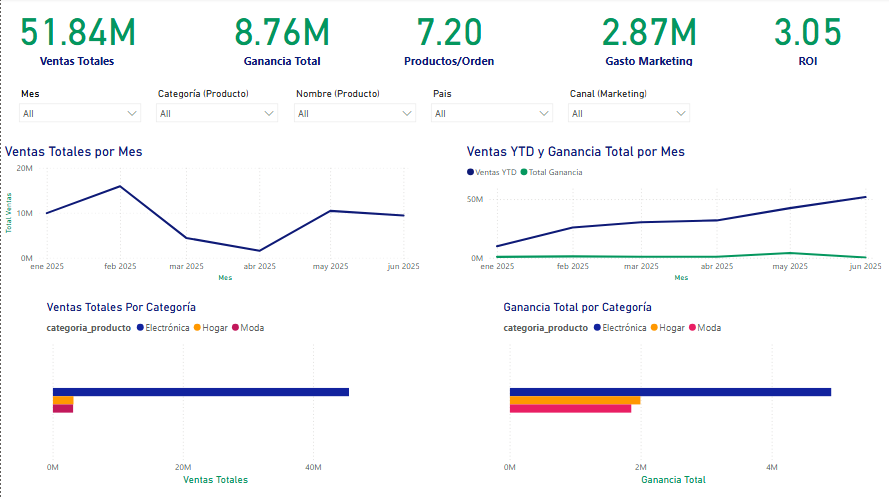

In [6]:
display(Image(filename="overview.PNG"))

# Detalle

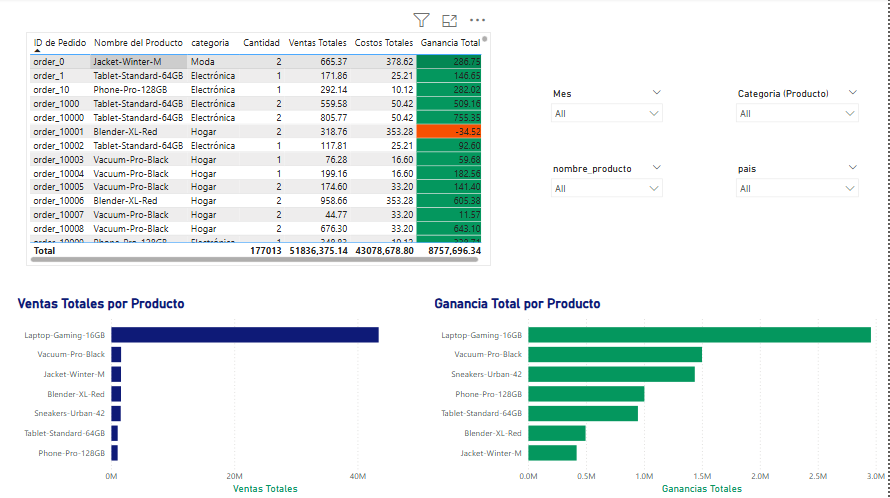

In [8]:
display(Image(filename="detalle.PNG"))

# Drill-through

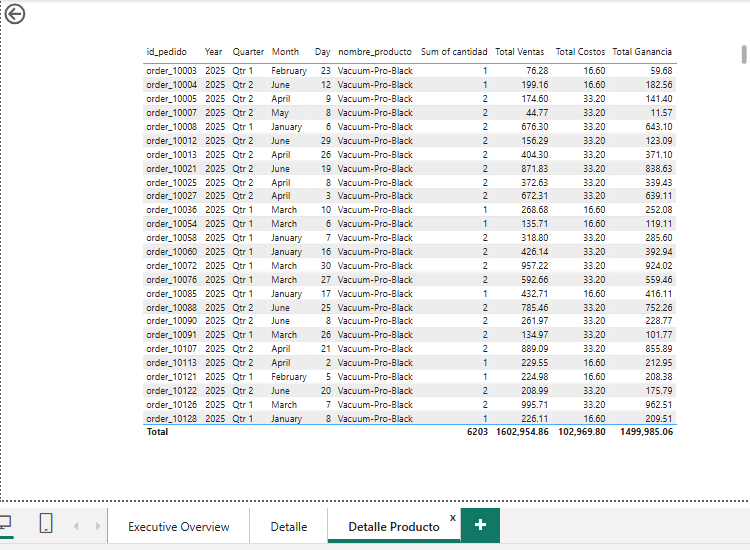

In [10]:
display(Image(filename="detalle_producto.PNG"))

---

### Enlace del Dashboard

In [ ]:

https://drive.google.com/drive/folders/1WsiTGxRa8ZKfcCIph-5aLkIcjShAMcyA?usp=drive_link